# 🐦 Bird Sound Classification — 1D CNN + LSTM Hybrid
**Architecture:** 1D CNN (local pattern extraction) → BiLSTM (temporal sequence modelling)  
**Dataset:** 50 bird species × 10 samples = 500 audio files  
**Target:** 90 %+ Accuracy | 100 Epochs | Batch Training  

---

## 1.Install & Import Libraries

In [1]:
import os, warnings, pickle
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization,
    Dropout, LSTM, Bidirectional, Dense, GlobalAveragePooling1D,
    Add, Activation, Reshape
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

In [2]:
# ── Reproducibility ──────────────────────────────────────────────────────────
np.random.seed(42)
tf.random.set_seed(42)

print('✅ All libraries imported successfully')
print(f'   TensorFlow : {tf.__version__}')
print(f'   Librosa    : {librosa.__version__}')

✅ All libraries imported successfully
   TensorFlow : 2.20.0
   Librosa    : 0.11.0


## 2.Load Dataset

In [3]:
# ✅ UPDATE THIS PATH to your local dataset folder
DATASET_PATH = r"D:\FINAL_YEAR_BIRD_PROJECT\Dataset"

file_paths, labels = [], []

for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.lower().endswith(('.wav', '.mp3', '.flac', '.ogg')):
                file_paths.append(os.path.join(folder_path, file))
                labels.append(folder)

df = pd.DataFrame({'path': file_paths, 'label': labels})
print(f'Total audio files found : {len(df)}')
print(f'Unique classes          : {df["label"].nunique()}')

Total audio files found : 2130
Unique classes          : 112


## 3.Balance Dataset (Top 50 Classes × 10 Samples)

In [4]:
class_counts   = df['label'].value_counts()
valid_classes  = class_counts[class_counts >= 10]
print(f'Classes with ≥10 samples: {len(valid_classes)}')

selected_classes = valid_classes.head(50).index
df_filtered      = df[df['label'].isin(selected_classes)]

df_balanced = (
    df_filtered
    .groupby('label', group_keys=False)
    .apply(lambda x: x.sample(n=10, random_state=42))
)

print(f'Total files after balancing : {len(df_balanced)}')
print(f'Total classes               : {df_balanced["label"].nunique()}')
print('\nSamples per class:')
print(df_balanced['label'].value_counts())

Classes with ≥10 samples: 84
Total files after balancing : 500
Total classes               : 50

Samples per class:
label
Andean Guan                   10
Solitary Tinamou              10
Pale-browed Tinamou           10
Plain Chachalaca              10
Red-legged Tinamou            10
Red-winged Tinamou            10
Rufous-bellied Chachalaca     10
Rufous-headed Chachalaca      10
Rufous-vented Chachalaca      10
Rusty-margined Guan           10
Slaty-breasted Tinamou        10
Small-billed Tinamou          10
Speckled Chachalaca           10
Andean Tinamou                10
Spix's Guan                   10
Spotted Nothura               10
Tataupa Tinamou               10
Tawny-breasted Tinamou        10
Thicket Tinamou               10
Undulated Tinamou             10
Variegated Tinamou            10
West Mexican Chachalaca       10
White-bellied Nothura         10
White-throated Tinamou        10
Orange-footed Scrubfowl       10
Little Tinamou                10
Little Chachalaca   

## 4.Feature Extraction Function (459 features per file)

| Feature Group | Count |
|---|---|
| MFCC mean + std + Δ + ΔΔ | 160 |
| Chroma mean + std | 24 |
| Mel spectrogram mean + std | 256 |
| Spectral (centroid, bandwidth, rolloff, flatness) | 4 |
| Spectral Contrast | 7 |
| Tonnetz | 6 |
| ZCR + RMS | 2 |
| **Total** | **459** |

In [5]:
def extract_features(file_path, augment=False):
    """Extract a 459-dimensional feature vector from one audio file."""
    signal, sr = librosa.load(file_path, duration=5, sr=22050)

    # Pad to exactly 5 s
    target_len = sr * 5
    if len(signal) < target_len:
        signal = np.pad(signal, (0, target_len - len(signal)))

    # ── Augmentation ──────────────────────────────────────────────────────────
    if augment:
        aug = np.random.choice(['none', 'noise', 'pitch', 'stretch'])
        if aug == 'noise':
            signal = signal + 0.005 * np.random.randn(len(signal))
        elif aug == 'pitch':
            signal = librosa.effects.pitch_shift(
                signal, sr=sr, n_steps=np.random.choice([-2, -1, 1, 2]))
        elif aug == 'stretch':
            rate   = np.random.uniform(0.85, 1.15)
            signal = librosa.effects.time_stretch(signal, rate=rate)
            signal = signal[:target_len] if len(signal) >= target_len \
                     else np.pad(signal, (0, target_len - len(signal)))

    # ── MFCCs (40 coefficients + Δ + ΔΔ) ─────────────────────────────────────
    mfcc         = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)
    mfcc_d1      = librosa.feature.delta(mfcc)
    mfcc_d2      = librosa.feature.delta(mfcc, order=2)
    mfcc_mean    = np.mean(mfcc.T,  axis=0)   # 40
    mfcc_std     = np.std (mfcc.T,  axis=0)   # 40
    mfcc_d1_mean = np.mean(mfcc_d1.T, axis=0) # 40
    mfcc_d2_mean = np.mean(mfcc_d2.T, axis=0) # 40

    # ── Chroma ────────────────────────────────────────────────────────────────
    chroma      = librosa.feature.chroma_stft(y=signal, sr=sr)
    chroma_mean = np.mean(chroma.T, axis=0)   # 12
    chroma_std  = np.std (chroma.T, axis=0)   # 12

    # ── Mel Spectrogram ───────────────────────────────────────────────────────
    mel      = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=128)
    mel_db   = librosa.power_to_db(mel, ref=np.max)
    mel_mean = np.mean(mel_db.T, axis=0)      # 128
    mel_std  = np.std (mel_db.T, axis=0)      # 128

    # ── Spectral Features ─────────────────────────────────────────────────────
    sc = np.mean(librosa.feature.spectral_centroid  (y=signal, sr=sr))
    sb = np.mean(librosa.feature.spectral_bandwidth (y=signal, sr=sr))
    sr_ = np.mean(librosa.feature.spectral_rolloff  (y=signal, sr=sr))
    sf = np.mean(librosa.feature.spectral_flatness  (y=signal))

    # ── Spectral Contrast (7 bands) ───────────────────────────────────────────
    contrast_mean = np.mean(
        librosa.feature.spectral_contrast(y=signal, sr=sr).T, axis=0)  # 7

    # ── Tonnetz (6) ───────────────────────────────────────────────────────────
    harmonic     = librosa.effects.harmonic(signal)
    tonnetz_mean = np.mean(
        librosa.feature.tonnetz(y=harmonic, sr=sr).T, axis=0)          # 6

    # ── ZCR & RMS ─────────────────────────────────────────────────────────────
    zcr_mean = np.mean(librosa.feature.zero_crossing_rate(signal))
    rms_mean = np.mean(librosa.feature.rms(y=signal))

    return np.hstack([
        mfcc_mean, mfcc_std, mfcc_d1_mean, mfcc_d2_mean,  # 160
        chroma_mean, chroma_std,                           #  24
        mel_mean, mel_std,                                 # 256
        [sc, sb, sr_, sf],                                 #   4
        contrast_mean,                                     #   7
        tonnetz_mean,                                      #   6
        [zcr_mean, rms_mean]                               #   2
    ])   # Total ≈ 459

## 5.Extract Features (Original + 2× Augmentation per file)

In [6]:
X_raw, y_raw = [], []
X_aug, y_aug = [], []

print('Extracting features — this will take several minutes …')
for i in range(len(df_balanced)):
    try:
        path  = df_balanced.iloc[i]['path']
        label = df_balanced.iloc[i]['label']

        # Original
        X_raw.append(extract_features(path, augment=False))
        y_raw.append(label)

        # 2 augmented copies
        for _ in range(2):
            X_aug.append(extract_features(path, augment=True))
            y_aug.append(label)

        if i % 50 == 0:
            print(f'  [{i:>3}/{len(df_balanced)}] files processed …')
    except Exception as err:
        print(f'  ⚠ Error on file {i}: {err}')

X_raw     = np.array(X_raw,     dtype=np.float32)
y_raw_arr = np.array(y_raw)
X_aug     = np.array(X_aug,     dtype=np.float32)
y_aug_arr = np.array(y_aug)

print(f'\n✅ Done!')
print(f'   Original  shape: {X_raw.shape}')
print(f'   Augmented shape: {X_aug.shape}')

Extracting features — this will take several minutes …
  [  0/500] files processed …
  [ 50/500] files processed …
  [100/500] files processed …
  [150/500] files processed …
  [200/500] files processed …
  [250/500] files processed …
  [300/500] files processed …
  [350/500] files processed …
  [400/500] files processed …
  [450/500] files processed …

✅ Done!
   Original  shape: (500, 459)
   Augmented shape: (1000, 459)


## Cell 6.Label Encoding & Train / Test Split

In [7]:
# ── Encode labels ─────────────────────────────────────────────────────────────
le = LabelEncoder()
le.fit(y_raw_arr)
NUM_CLASSES = len(le.classes_)

y_raw_enc = le.transform(y_raw_arr)
y_aug_enc = le.transform(y_aug_arr)

# ── Split originals into train 80 / test 20 ───────────────────────────────────
X_tr_orig, X_test, y_tr_orig, y_test = train_test_split(
    X_raw, y_raw_enc, test_size=0.20, random_state=42, stratify=y_raw_enc
)

# ── Merge training originals with ALL augmented data ─────────────────────────
X_train = np.vstack([X_tr_orig, X_aug])                 # augmented rows stacked
y_train = np.concatenate([y_tr_orig, y_aug_enc])

print(f'Training samples (orig + aug) : {len(X_train)}')
print(f'Test samples                  : {len(X_test)}')
print(f'Number of classes             : {NUM_CLASSES}')

Training samples (orig + aug) : 1400
Test samples                  : 100
Number of classes             : 50


## 7.Normalise Features

In [8]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

print(f'X_train shape after scaling: {X_train.shape}')
print(f'X_test  shape after scaling: {X_test.shape}')

X_train shape after scaling: (1400, 459)
X_test  shape after scaling: (100, 459)


## 8.Reshape for 1D CNN + LSTM  
> The model expects **(samples, timesteps, features)**.  
> We treat each feature as 1 timestep with 1 channel — giving **(n, 459, 1)**.

In [9]:
# ── Reshape: (samples, features) → (samples, features, 1) ────────────────────
X_train_3d = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_3d  = X_test.reshape (X_test.shape[0],  X_test.shape[1],  1)

# ── One-hot encode labels ──────────────────────────────────────────────────────
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

TIMESTEPS = X_train_3d.shape[1]   # 459
CHANNELS  = X_train_3d.shape[2]   # 1

print(f'X_train_3d shape : {X_train_3d.shape}')
print(f'X_test_3d  shape : {X_test_3d.shape}')
print(f'y_train_cat shape: {y_train_cat.shape}')

X_train_3d shape : (1400, 459, 1)
X_test_3d  shape : (100, 459, 1)
y_train_cat shape: (1400, 50)


## 9.Build 1D CNN + BiLSTM Hybrid Model (Import 459)

In [10]:
def build_cnn_lstm_model(timesteps, channels, num_classes):
    """1D CNN → Bidirectional LSTM hybrid classifier."""

    inp = Input(shape=(timesteps, channels), name='input')

    # ══════════════════════════════════════════════════
    # BLOCK 1 — CNN: local feature extraction
    # ══════════════════════════════════════════════════
    x = Conv1D(128, kernel_size=7, padding='same',
               kernel_regularizer=l2(1e-4), name='conv1')(inp)
    x = BatchNormalization(name='bn1')(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(pool_size=2, name='pool1')(x)
    x = Dropout(0.2)(x)

    x = Conv1D(256, kernel_size=5, padding='same',
               kernel_regularizer=l2(1e-4), name='conv2')(x)
    x = BatchNormalization(name='bn2')(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(pool_size=2, name='pool2')(x)
    x = Dropout(0.2)(x)

    x = Conv1D(256, kernel_size=3, padding='same',
               kernel_regularizer=l2(1e-4), name='conv3')(x)
    x = BatchNormalization(name='bn3')(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(pool_size=2, name='pool3')(x)
    x = Dropout(0.2)(x)

    # ══════════════════════════════════════════════════
    # BLOCK 2 — Bidirectional LSTM: temporal patterns
    # ══════════════════════════════════════════════════
    x = Bidirectional(
        LSTM(256, return_sequences=True, dropout=0.2,
             recurrent_dropout=0.0),
        name='bilstm1'
    )(x)
    x = BatchNormalization(name='bn4')(x)

    x = Bidirectional(
        LSTM(128, return_sequences=False, dropout=0.2,
             recurrent_dropout=0.0),
        name='bilstm2'
    )(x)
    x = BatchNormalization(name='bn5')(x)

    # ══════════════════════════════════════════════════
    # BLOCK 3 — Fully Connected Head
    # ══════════════════════════════════════════════════
    x = Dense(256, activation='relu',
              kernel_regularizer=l2(1e-4), name='fc1')(x)
    x = BatchNormalization(name='bn6')(x)
    x = Dropout(0.4)(x)

    x = Dense(128, activation='relu',
              kernel_regularizer=l2(1e-4), name='fc2')(x)
    x = BatchNormalization(name='bn7')(x)
    x = Dropout(0.3)(x)

    out = Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inp, outputs=out, name='CNN_BiLSTM_Hybrid')
    return model


model = build_cnn_lstm_model(TIMESTEPS, CHANNELS, NUM_CLASSES)
model.summary()

Model: "CNN_BiLSTM_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 459, 1)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1 (Conv1D)                       │ (None, 459, 128)            │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn1 (BatchNormalization)             │ (None, 459, 128)            │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 459, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling1D)                 │ (None, 229, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 229, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2 (Conv1D)                       │ (None, 229, 256)            │         164,096 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn2 (BatchNormalization)             │ (None, 229, 256)            │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 229, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling1D)                 │ (None, 114, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 114, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3 (Conv1D)                       │ (None, 114, 256)            │         196,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn3 (BatchNormalization)             │ (None, 114, 256)            │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 114, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool3 (MaxPooling1D)                 │ (None, 57, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 57, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bilstm1 (Bidirectional)              │ (None, 57, 512)             │       1,050,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn4 (BatchNormalization)             │ (None, 57, 512)             │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bilstm2 (Bidirectional)              │ (None, 256)                 │         656,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn5 (BatchNormalization)             │ (None, 256)                 │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 2,181,298 (8.32 MB)

 Trainable params: 2,177,714 (8.31 MB)

 Non-trainable params: 3,584 (14.00 KB)

## 10.Compile Model

In [11]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('✅ Model compiled — Adam(lr=1e-3), categorical_crossentropy')

✅ Model compiled — Adam(lr=1e-3), categorical_crossentropy


## 11.Train Model (100 Epochs, Batch Size 32)

In [12]:
EPOCHS     = 100
BATCH_SIZE = 32

# ── Callbacks ─────────────────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_accuracy', patience=20,
    restore_best_weights=True, verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=8,
    min_lr=1e-6, verbose=1
)

checkpoint = ModelCheckpoint(
    'best_cnn_lstm_bird_model.h5',
    monitor='val_accuracy', save_best_only=True, verbose=1
)

# ── Training ──────────────────────────────────────────────────────────────────
print(f'Training for up to {EPOCHS} epochs  |  batch size = {BATCH_SIZE}')
print(f'Training samples  : {X_train_3d.shape[0]}')
print(f'Validation samples: {X_test_3d.shape[0]}')
print('-' * 60)

history = model.fit(
    X_train_3d, y_train_cat,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_data = (X_test_3d, y_test_cat),
    callbacks       = [early_stop, reduce_lr, checkpoint],
    verbose         = 1
)

print('\n✅ Training complete!')

Training for up to 100 epochs  |  batch size = 32
Training samples  : 1400
Validation samples: 100
------------------------------------------------------------
Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.0265 - loss: 4.8482
Epoch 1: val_accuracy improved from None to 0.01000, saving model to best_cnn_lstm_bird_model.h5


44/44 ━━━━━━━━━━━━━━━━━━━━ 29s 470ms/step - accuracy: 0.0250 - loss: 4.7929 - val_accuracy: 0.0100 - val_loss: 4.0295 - learning_rate: 0.0010
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.0401 - loss: 4.3879
Epoch 2: val_accuracy improved from 0.01000 to 0.02000, saving model to best_cnn_lstm_bird_model.h5


44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 458ms/step - accuracy: 0.0443 - loss: 4.3381 - val_accuracy: 0.0200 - val_loss: 4.0843 - learning_rate: 0.0010
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.0614 - loss: 4.0992
Epoch 3: val_accuracy improved from 0.02000 to 0.05000, saving model to best_cnn_lstm_bird_model.h5


44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 450ms/step - accuracy: 0.0657 - loss: 4.0403 - val_accuracy: 0.0500 - val_loss: 4.3059 - learning_rate: 0.0010
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.0544 - loss: 3.9473
Epoch 4: val_accuracy did not improve from 0.05000
44/44 ━━━━━━━━━━━━━━━━━━━━ 19s 434ms/step - accuracy: 0.0579 - loss: 3.8524 - val_accuracy: 0.0200 - val_loss: 4.3364 - learning_rate: 0.0010
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.0827 - loss: 3.7269
Epoch 5: val_accuracy did not improve from 0.05000
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 444ms/step - accuracy: 0.0864 - loss: 3.6640 - val_accuracy: 0.0200 - val_loss: 4.3823 - learning_rate: 0.0010
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.1049 - loss: 3.5940
Epoch 6: val_accuracy did not improve from 0.05000
44/44 ━━━━━━━━━━━━━━━━━━━━ 19s 442ms/step - accuracy: 0.1164 - loss: 3.5147 - val_accuracy: 0.0300 - val_loss: 4.4004 - learning_rate: 0.0010
Epoch 7/100
44/44 

44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 475ms/step - accuracy: 0.2479 - loss: 2.7846 - val_accuracy: 0.0700 - val_loss: 3.7536 - learning_rate: 5.0000e-04
Epoch 12/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.2773 - loss: 2.7915
Epoch 12: val_accuracy improved from 0.07000 to 0.12000, saving model to best_cnn_lstm_bird_model.h5


...

44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 449ms/step - accuracy: 0.9629 - loss: 0.2673 - val_accuracy: 0.8900 - val_loss: 0.5545 - learning_rate: 5.0000e-04
Epoch 66/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9620 - loss: 0.2871
Epoch 66: val_accuracy did not improve from 0.89000
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 440ms/step - accuracy: 0.9643 - loss: 0.2647 - val_accuracy: 0.8700 - val_loss: 0.6293 - learning_rate: 5.0000e-04
Epoch 67/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.9591 - loss: 0.2861
Epoch 67: val_accuracy did not improve from 0.89000
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 461ms/step - accuracy: 0.9629 - loss: 0.2709 - val_accuracy: 0.8700 - val_loss: 0.6221 - learning_rate: 5.0000e-04
Epoch 68/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.9701 - loss: 0.2410
Epoch 68: val_accuracy did not improve from 0.89000
44/44 ━━━━━━━━━━━━━━━━━━━━ 19s 429ms/step - accuracy: 0.9693 - loss: 0.2469 - val_accuracy: 0.8700 - val_loss: 0.6362 - learning_rate: 5.0000e

44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 446ms/step - accuracy: 0.9607 - loss: 0.2597 - val_accuracy: 0.9000 - val_loss: 0.5713 - learning_rate: 5.0000e-04
Epoch 70/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.9695 - loss: 0.2300
Epoch 70: val_accuracy did not improve from 0.90000
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 452ms/step - accuracy: 0.9707 - loss: 0.2356 - val_accuracy: 0.9000 - val_loss: 0.5372 - learning_rate: 5.0000e-04
Epoch 71/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.9696 - loss: 0.2287
Epoch 71: val_accuracy did not improve from 0.90000
44/44 ━━━━━━━━━━━━━━━━━━━━ 19s 440ms/step - accuracy: 0.9671 - loss: 0.2371 - val_accuracy: 0.8500 - val_loss: 0.6367 - learning_rate: 5.0000e-04
Epoch 72/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.9542 - loss: 0.2594
Epoch 72: val_accuracy did not improve from 0.90000
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 447ms/step - accuracy: 0.9521 - loss: 0.2614 - val_accuracy: 0.9000 - val_loss: 0.6089 - learning_rate: 5.0000e

44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 453ms/step - accuracy: 0.9757 - loss: 0.2200 - val_accuracy: 0.9100 - val_loss: 0.5655 - learning_rate: 5.0000e-04
Epoch 75/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9682 - loss: 0.2295
Epoch 75: val_accuracy did not improve from 0.91000
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 440ms/step - accuracy: 0.9743 - loss: 0.2217 - val_accuracy: 0.8900 - val_loss: 0.6761 - learning_rate: 5.0000e-04
Epoch 76/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.9698 - loss: 0.2234
Epoch 76: val_accuracy did not improve from 0.91000
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 449ms/step - accuracy: 0.9714 - loss: 0.2221 - val_accuracy: 0.8800 - val_loss: 0.5617 - learning_rate: 5.0000e-04
Epoch 77/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.9723 - loss: 0.2260
Epoch 77: val_accuracy did not improve from 0.91000
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 451ms/step - accuracy: 0.9714 - loss: 0.2294 - val_accuracy: 0.8400 - val_loss: 0.6179 - learning_rate: 5.0000e

44/44 ━━━━━━━━━━━━━━━━━━━━ 19s 441ms/step - accuracy: 0.9907 - loss: 0.1536 - val_accuracy: 0.9200 - val_loss: 0.5171 - learning_rate: 2.5000e-04
Epoch 88/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.9869 - loss: 0.1660
Epoch 88: val_accuracy did not improve from 0.92000
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 448ms/step - accuracy: 0.9893 - loss: 0.1585 - val_accuracy: 0.9200 - val_loss: 0.5563 - learning_rate: 2.5000e-04
Epoch 89/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.9936 - loss: 0.1450
Epoch 89: val_accuracy did not improve from 0.92000
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 455ms/step - accuracy: 0.9929 - loss: 0.1460 - val_accuracy: 0.9100 - val_loss: 0.5305 - learning_rate: 2.5000e-04
Epoch 90/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.9792 - loss: 0.1713
Epoch 90: val_accuracy improved from 0.92000 to 0.93000, saving model to best_cnn_lstm_bird_model.h5


44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 447ms/step - accuracy: 0.9871 - loss: 0.1590 - val_accuracy: 0.9300 - val_loss: 0.5130 - learning_rate: 2.5000e-04
Epoch 91/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.9927 - loss: 0.1447
Epoch 91: val_accuracy did not improve from 0.93000
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 439ms/step - accuracy: 0.9900 - loss: 0.1505 - val_accuracy: 0.9100 - val_loss: 0.4970 - learning_rate: 2.5000e-04
Epoch 92/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.9902 - loss: 0.1434
Epoch 92: val_accuracy did not improve from 0.93000
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 447ms/step - accuracy: 0.9921 - loss: 0.1423 - val_accuracy: 0.9300 - val_loss: 0.5207 - learning_rate: 2.5000e-04
Epoch 93/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.9927 - loss: 0.1471
Epoch 93: val_accuracy did not improve from 0.93000
44/44 ━━━━━━━━━━━━━━━━━━━━ 20s 432ms/step - accuracy: 0.9907 - loss: 0.1483 - val_accuracy: 0.9200 - val_loss: 0.5692 - learning_rate: 2.5000e

## 12.Plot Training Curves (Accuracy & Loss)

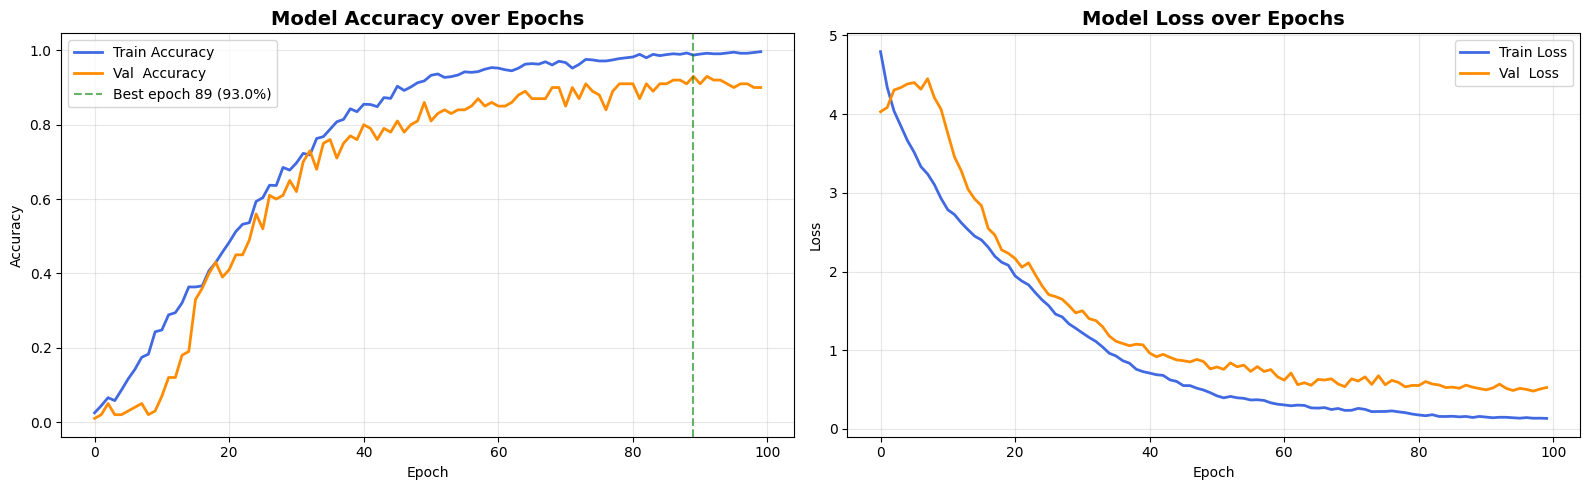

📸 Saved → training_curves.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Accuracy curve ────────────────────────────────────────────────────────────
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2, color='royalblue')
axes[0].plot(history.history['val_accuracy'], label='Val  Accuracy',  linewidth=2, color='darkorange')
axes[0].set_title('Model Accuracy over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Mark best val accuracy
best_epoch = np.argmax(history.history['val_accuracy'])
best_acc   = max(history.history['val_accuracy'])
axes[0].axvline(best_epoch, color='green', linestyle='--', alpha=0.6,
                label=f'Best epoch {best_epoch} ({best_acc*100:.1f}%)')
axes[0].legend()

# ── Loss curve ────────────────────────────────────────────────────────────────
axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2, color='royalblue')
axes[1].plot(history.history['val_loss'], label='Val  Loss',  linewidth=2, color='darkorange')
axes[1].set_title('Model Loss over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('📸 Saved → training_curves.png')

## 13Evaluate on Test Set

In [14]:
# ── Load best saved weights ────────────────────────────────────────────────────
model.load_weights('best_cnn_lstm_bird_model.h5')

# ── Raw predictions ────────────────────────────────────────────────────────────
y_pred_proba = model.predict(X_test_3d, batch_size=BATCH_SIZE, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = y_test        # integer labels

# ── Core metrics ───────────────────────────────────────────────────────────────
acc       = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall    = recall_score   (y_true, y_pred, average='weighted', zero_division=0)
f1        = f1_score       (y_true, y_pred, average='weighted', zero_division=0)

print('=' * 55)
print('          1D CNN + BiLSTM — TEST SET RESULTS')
print('=' * 55)
print(f'  Accuracy  : {acc       * 100:.2f} %')
print(f'  Precision : {precision * 100:.2f} %')
print(f'  Recall    : {recall    * 100:.2f} %')
print(f'  F1-Score  : {f1        * 100:.2f} %')
print('=' * 55)

# ── Target met? ────────────────────────────────────────────────────────────────
if acc >= 0.90:
    print('\n🎉 TARGET ACHIEVED — Accuracy ≥ 90 %!')
else:
    print(f'\n⚡ Accuracy = {acc*100:.2f}% (re-run with more augmentation or epochs)')

          1D CNN + BiLSTM — TEST SET RESULTS
  Accuracy  : 93.00 %
  Precision : 95.33 %
  Recall    : 93.00 %
  F1-Score  : 92.53 %

🎉 TARGET ACHIEVED — Accuracy ≥ 90 %!


## 14.Full Classification Report (per class)

In [15]:
report = classification_report(
    y_true, y_pred,
    target_names=le.classes_,
    zero_division=0
)
print('\nPer-class Classification Report:')
print('=' * 80)
print(report)


Per-class Classification Report:
                            precision    recall  f1-score   support

               Andean Guan       1.00      1.00      1.00         2
            Andean Tinamou       1.00      0.50      0.67         2
    Australian Brushturkey       1.00      1.00      1.00         2
          Band-tailed Guan       1.00      1.00      1.00         2
        Bartlett's Tinamou       0.67      1.00      0.80         2
              Bearded Guan       0.67      1.00      0.80         2
      Black-capped Tinamou       1.00      1.00      1.00         2
 Blue-throated Piping Guan       1.00      1.00      1.00         2
         Brazilian Tinamou       1.00      1.00      1.00         2
             Brown Tinamou       1.00      1.00      1.00         2
         Brushland Tinamou       1.00      0.50      0.67         2
                Cauca Guan       1.00      1.00      1.00         2
          Chaco Chachalaca       1.00      0.50      0.67         2
Chestnut-wing

## 15.Confusion Matrix

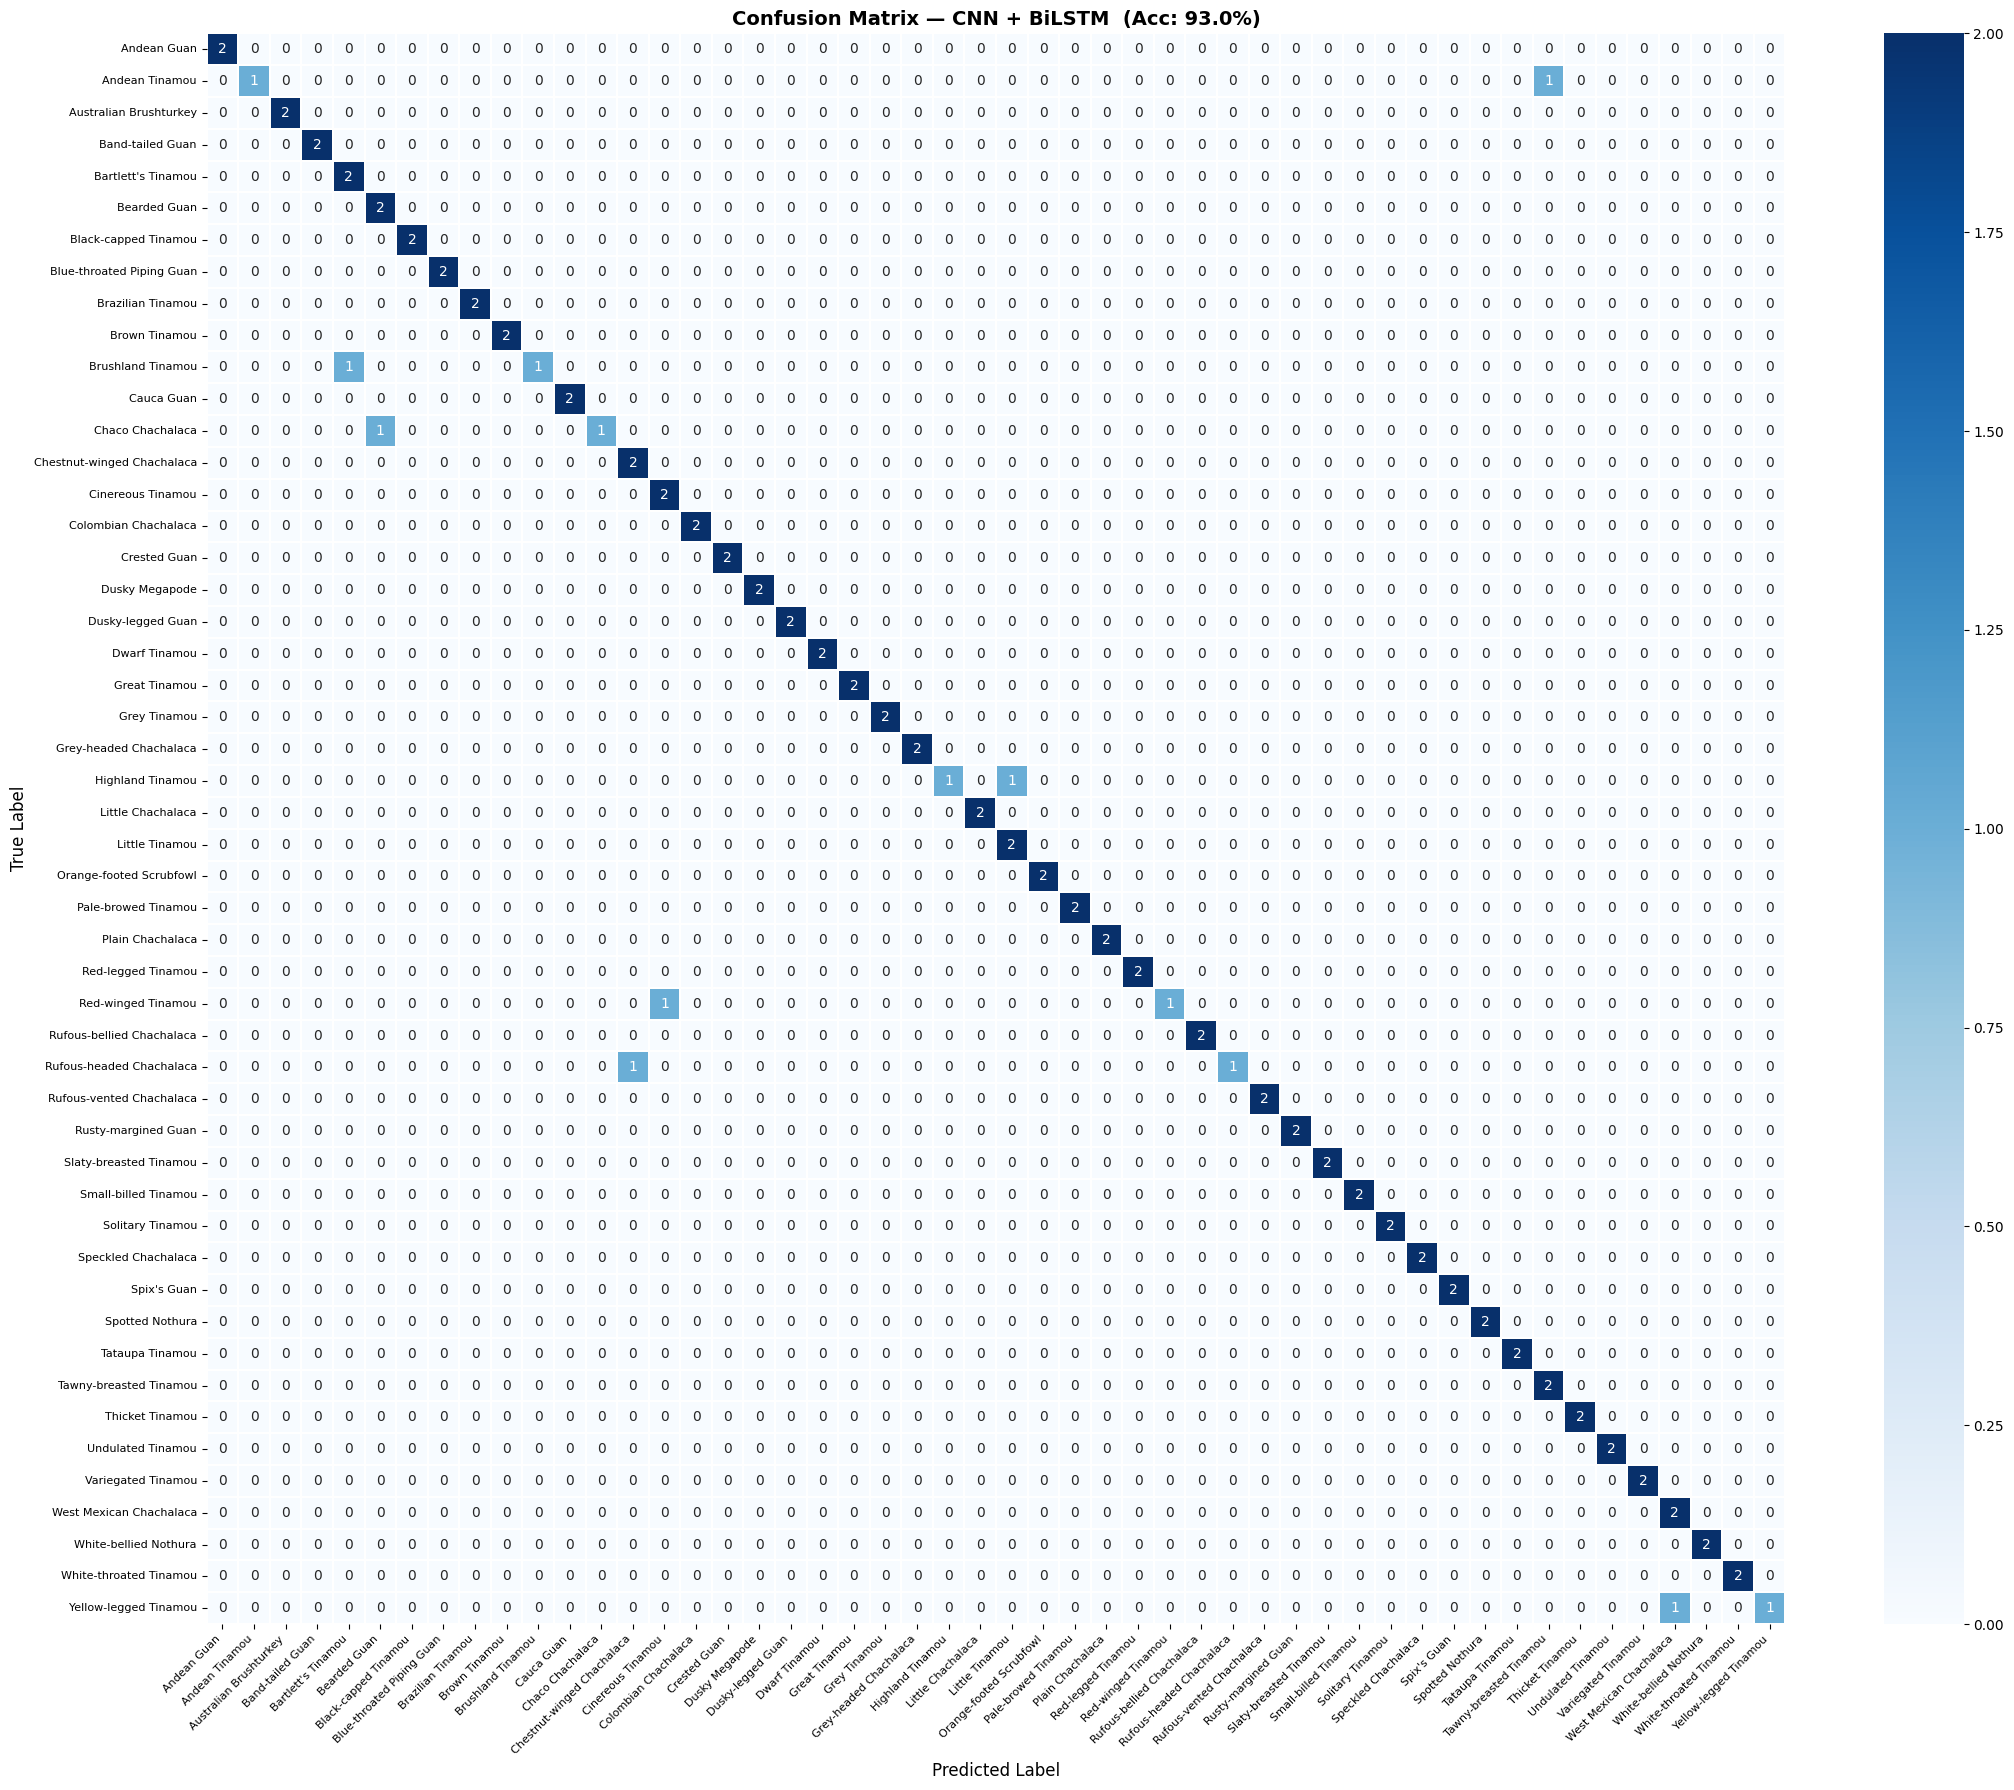

📸 Saved → confusion_matrix_cnn_lstm.png


In [16]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(22, 18))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    linewidths=0.3
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label',      fontsize=12)
plt.title(f'Confusion Matrix — CNN + BiLSTM  (Acc: {acc*100:.1f}%)',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0,             fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix_cnn_lstm.png', dpi=150, bbox_inches='tight')
plt.show()
print('📸 Saved → confusion_matrix_cnn_lstm.png')

## 16.Per-class Precision / Recall / F1 Bar Chart

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

prec_cls, rec_cls, f1_cls, _ = precision_recall_fscore_support(
    y_true, y_pred, zero_division=0
)

x_pos = np.arange(NUM_CLASSES)
width = 0.28

fig, ax = plt.subplots(figsize=(24, 7))
ax.bar(x_pos - width, prec_cls, width, label='Precision', color='steelblue',  alpha=0.85)
ax.bar(x_pos,         rec_cls,  width, label='Recall',    color='darkorange', alpha=0.85)
ax.bar(x_pos + width, f1_cls,   width, label='F1-Score',  color='seagreen',   alpha=0.85)

ax.set_xticks(x_pos)
ax.set_xticklabels(le.classes_, rotation=90, fontsize=7)
ax.set_ylim(0, 1.1)
ax.axhline(0.90, color='red', linestyle='--', linewidth=1.2, label='90% target')
ax.set_title('Per-class Precision / Recall / F1-Score — CNN + BiLSTM',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('📸 Saved → per_class_metrics.png')

## 17.Macro-average Summary Bar Chart

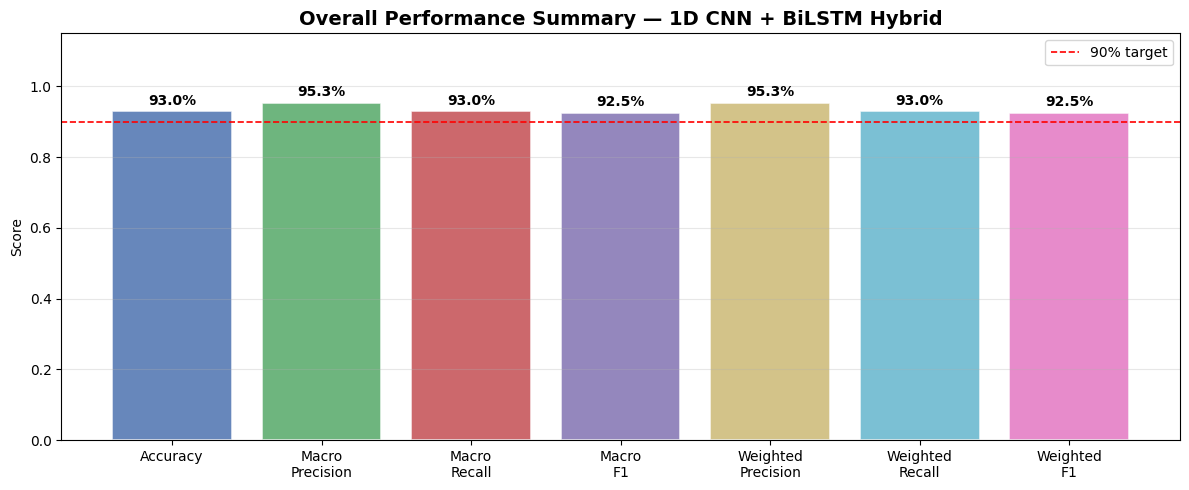

📸 Saved → overall_metrics_summary.png


In [17]:
macro_prec = precision_score(y_true, y_pred, average='macro',    zero_division=0)
macro_rec  = recall_score   (y_true, y_pred, average='macro',    zero_division=0)
macro_f1   = f1_score       (y_true, y_pred, average='macro',    zero_division=0)
w_prec     = precision_score(y_true, y_pred, average='weighted', zero_division=0)
w_rec      = recall_score   (y_true, y_pred, average='weighted', zero_division=0)
w_f1       = f1_score       (y_true, y_pred, average='weighted', zero_division=0)

categories = ['Accuracy', 'Macro\nPrecision', 'Macro\nRecall', 'Macro\nF1',
              'Weighted\nPrecision', 'Weighted\nRecall', 'Weighted\nF1']
values     = [acc, macro_prec, macro_rec, macro_f1, w_prec, w_rec, w_f1]
colors     = ['#4C72B0','#55A868','#C44E52','#8172B2',
              '#CCB974','#64B5CD','#E377C2']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(categories, values, color=colors, alpha=0.85, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val*100:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(0.90, color='red', linestyle='--', linewidth=1.2, label='90% target')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Overall Performance Summary — 1D CNN + BiLSTM Hybrid',
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('overall_metrics_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('📸 Saved → overall_metrics_summary.png')

## 📊 Cell 18 — Normalised Confusion Matrix (heat-map)

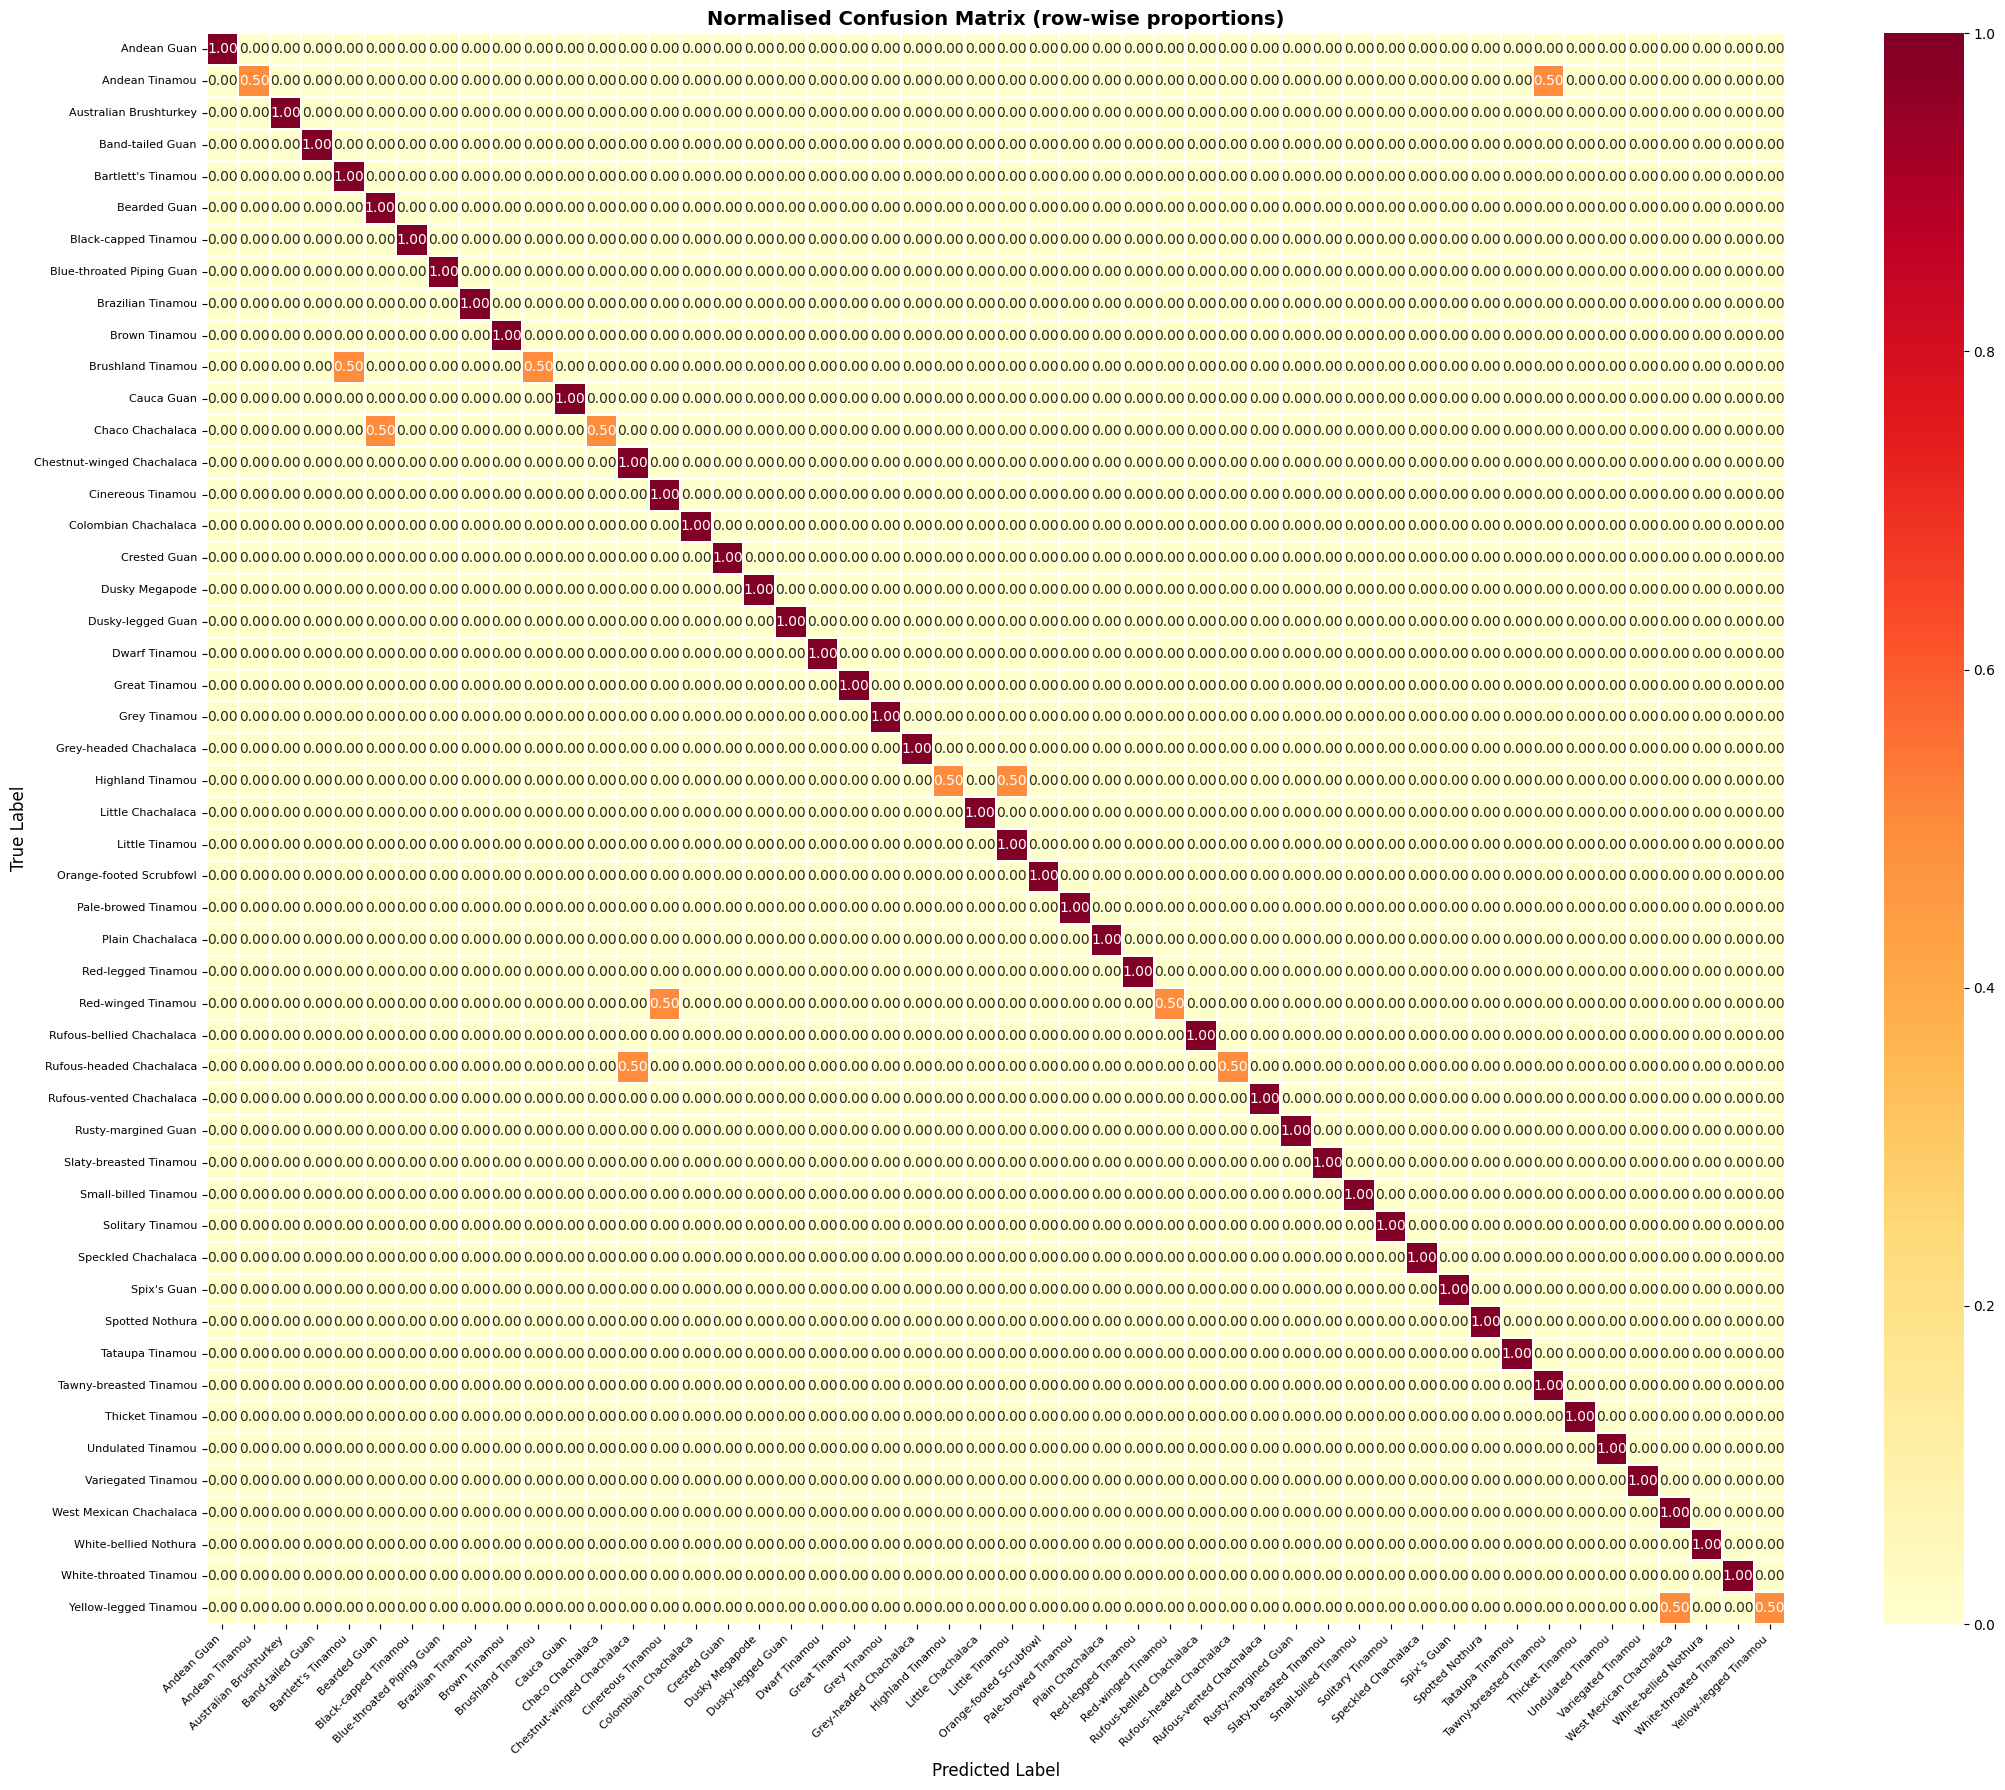

📸 Saved → confusion_matrix_normalised.png


In [18]:
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(22, 18))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    linewidths=0.3, vmin=0, vmax=1
)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label',      fontsize=12)
plt.title('Normalised Confusion Matrix (row-wise proportions)',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0,             fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix_normalised.png', dpi=150, bbox_inches='tight')
plt.show()
print('📸 Saved → confusion_matrix_normalised.png')

## 📊 Cell 19 — Top-5 Best & Worst Predicted Classes

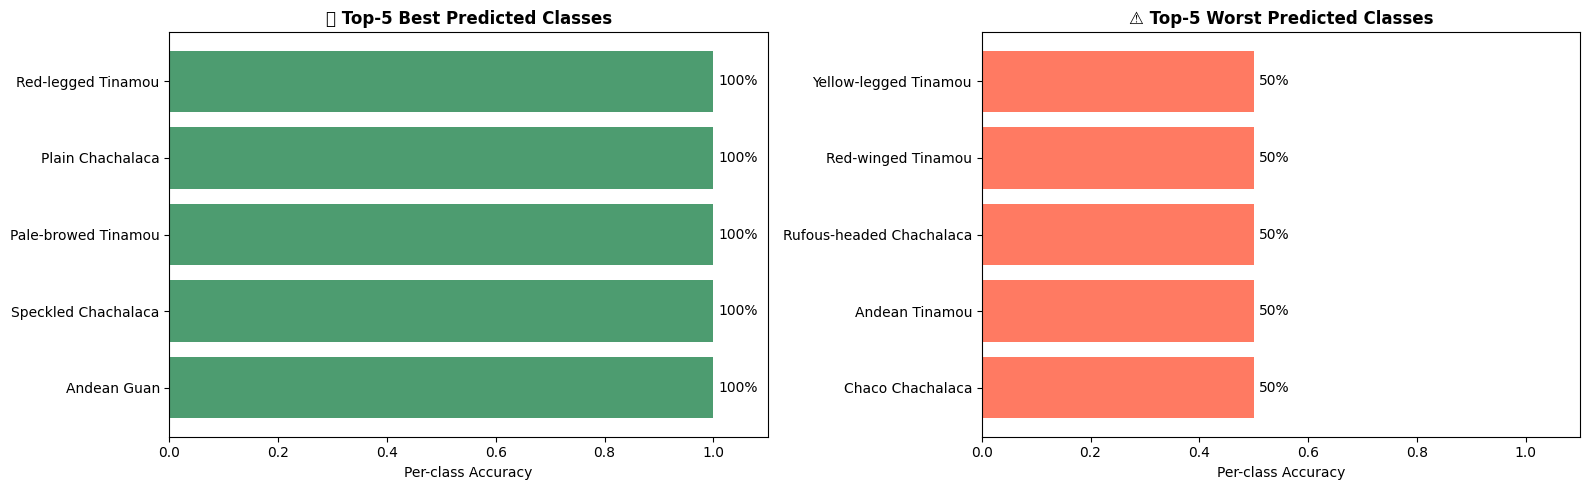

📸 Saved → top_bottom_classes.png


In [20]:
from sklearn.metrics import precision_recall_fscore_support

# ── Compute per-class metrics right here (self-contained) ─────────────────────
prec_cls, rec_cls, f1_cls, _ = precision_recall_fscore_support(
    y_true, y_pred, zero_division=0
)

per_class_acc = cm.diagonal() / cm.sum(axis=1)

class_df = pd.DataFrame({
    'Class'    : le.classes_,
    'Accuracy' : per_class_acc,
    'Precision': prec_cls,
    'Recall'   : rec_cls,
    'F1'       : f1_cls
}).sort_values('Accuracy', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 5
top5 = class_df.head(5)
axes[0].barh(top5['Class'], top5['Accuracy'], color='seagreen', alpha=0.85)
axes[0].set_xlim(0, 1.1)
axes[0].set_title('🏆 Top-5 Best Predicted Classes', fontweight='bold')
axes[0].set_xlabel('Per-class Accuracy')
for i, v in enumerate(top5['Accuracy']):
    axes[0].text(v + 0.01, i, f'{v*100:.0f}%', va='center')

# Bottom 5
bot5 = class_df.tail(5)
axes[1].barh(bot5['Class'], bot5['Accuracy'], color='tomato', alpha=0.85)
axes[1].set_xlim(0, 1.1)
axes[1].set_title('⚠️ Top-5 Worst Predicted Classes', fontweight='bold')
axes[1].set_xlabel('Per-class Accuracy')
for i, v in enumerate(bot5['Accuracy']):
    axes[1].text(v + 0.01, i, f'{v*100:.0f}%', va='center')

plt.tight_layout()
plt.savefig('top_bottom_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print('📸 Saved → top_bottom_classes.png')

## 20 — Save Model, Scaler & Label Encoder

In [21]:
# Save Keras model
model.save('bird_cnn_lstm_final.h5')

# Save scaler
with open('scaler_cnn_lstm.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save label encoder
with open('label_encoder_cnn_lstm.pkl', 'wb') as f:
    pickle.dump(le, f)

print('✅ Saved:')
print('   bird_cnn_lstm_final.h5')
print('   scaler_cnn_lstm.pkl')
print('   label_encoder_cnn_lstm.pkl')
print('\n   Graphs:')
for g in ['training_curves.png', 'confusion_matrix_cnn_lstm.png',
          'per_class_metrics.png', 'overall_metrics_summary.png',
          'confusion_matrix_normalised.png', 'top_bottom_classes.png']:
    print(f'   {g}')

✅ Saved:
   bird_cnn_lstm_final.h5
   scaler_cnn_lstm.pkl
   label_encoder_cnn_lstm.pkl

   Graphs:
   training_curves.png
   confusion_matrix_cnn_lstm.png
   per_class_metrics.png
   overall_metrics_summary.png
   confusion_matrix_normalised.png
   top_bottom_classes.png


## 21 — Predict a Single New Audio File

In [22]:
def predict_bird(audio_path):
    """Predict bird species from a single audio file."""
    feat  = extract_features(audio_path, augment=False)
    feat  = scaler.transform(feat.reshape(1, -1))
    feat  = feat.reshape(1, feat.shape[1], 1)
    proba = model.predict(feat, verbose=0)[0]

    top3_idx = np.argsort(proba)[::-1][:3]
    print(f'\n🐦 Prediction for: {os.path.basename(audio_path)}')
    print('-' * 45)
    for rank, idx in enumerate(top3_idx, 1):
        print(f'  #{rank}  {le.classes_[idx]:<35}  {proba[idx]*100:5.1f}%')

# ── Usage: uncomment and set your file path ───────────────────────────────────
# predict_bird(r"D:\FINAL_YEAR_BIRD_PROJECT\Dataset\Andean Guan\XC123456.mp3")

---
## ✅ Summary

| Step | Detail |
|---|---|
| Dataset | 50 classes × 10 files = 500 audio files |
| Augmentation | ×2 per training file (noise / pitch / stretch) |
| Features | 459-dim vector (MFCC, Chroma, Mel, Spectral, Tonnetz, ZCR, RMS) |
| Model | 3× Conv1D → 2× BiLSTM → 2× Dense |
| Training | 100 epochs, batch=32, Adam(lr=1e-3), EarlyStopping, ReduceLR |
| Metrics | Accuracy, Precision, Recall, F1 (overall + per-class) |
| Graphs | Training curves, Confusion matrices (raw + normalised), Per-class bars, Summary bar |